<a href="https://colab.research.google.com/github/Saikonfate/TDE1-IA/blob/TDE-01/EDA_An%C3%A1lise_de_Revis%C3%B5es_de_Compras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TDE1 - Análise de Revisões de Compras
Dataset: Flipkart Laptop Reviews — Kaggle

Discentes: Maria Taliciane Pereira da Silva, Wesley Furtado Pessoa, Michel Gomes Pinheiro, Ingrid Sampaio Angelim do Nascimento, Moryak Samyak Arrais Benicio, José Daniel Macêdo Fechine, Clara Sobreira Vidal e Lia Costa Andrade

Professor: Alexandro Oliveira Alexandrino

Disciplina: Inteligência Artificial

Data: 30/08/2026

In [ ]:
import os
import re
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliotecas importadas e ambiente configurado com sucesso.")

Bibliotecas importadas e ambiente configurado com sucesso.


In [ ]:
import kagglehub

path = kagglehub.dataset_download("gitadityamaddali/flipkart-laptop-reviews")

arquivos_csv = glob.glob(os.path.join(path, "*.csv"))
assert arquivos_csv, f"Nenhum arquivo CSV encontrado em: {path}"
df = pd.read_csv(arquivos_csv[0])

print("Path to dataset files:", path)
print("DataFrame carregado:", os.path.basename(arquivos_csv[0]), df.shape)

Using Colab cache for faster access to the 'flipkart-laptop-reviews' dataset.
Path to dataset files: /kaggle/input/flipkart-laptop-reviews
DataFrame carregado: laptops_dataset_final_600.csv (24113, 7)


In [ ]:
# Garantia de que o DataFrame principal foi criado corretamente antes de qualquer análise
assert "df" in globals(), "O DataFrame 'df' não foi criado. Verifique a célula de carregamento acima."
assert df.shape[0] > 0, "O DataFrame está vazio."
df.head(3)

,product_name,overall_rating,no_ratings,no_reviews,rating,title,review
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Perfect product!,"Loved it, it's my first MacBook that I earned from my hardwork 🥺❤️"
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Fabulous!,Battery lasted longer than my first relationship (2 days).\nListening to Ari...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Fabulous!,Such a great deal.. very happy with the performance and battery life..Origio...


## 1. Contextualização e Enquadramento do Estudo


A **Flipkart**, um dos pilares do comércio eletrônico indiano, espelha a dinâmica global de grandes varejistas online, onde milhões de consumidores compartilham suas percepções sobre produtos adquiridos. Neste contexto, o foco recai sobre as avaliações de **notebooks/laptops**. Cada avaliação constitui um compêndio de informações: uma **classificação estelar de 1 a 5**, um **título conciso** (e.g., 'Excelente', 'Satisfatório', 'Apenas razoável') e um **discurso textual livre** que narra a experiência do usuário.

O cerne deste projeto reside na seguinte interrogação: **seria possível inferir a nota (rating) atribuída por um cliente com base exclusivamente no conteúdo textual de sua avaliação?** Esta questão possui relevância prática considerável, uma vez que organizações frequentemente se deparam com volumes massivos de texto não estruturado (avaliações, tíquetes de suporte, comentários em mídias sociais) nem sempre acompanhados de uma avaliação numérica explícita. Adicionalmente, a nota pode estar ausente, ser imprecisa ou desatualizada. A capacidade de um classificador de sentimento ou de nota permite o **monitoramento escalável da satisfação do cliente**, transcendendo a dependência da inserção manual de classificações.

### Propósito da Análise Atual

Esta fase inicial do TDE1, tem como desígnio primordial a **compreensão aprofundada dos dados antes de qualquer incursão em modelagem**. Almeja-se desvendar a estrutura, a integridade, a distribuição e as inter-relações entre as variáveis. As descobertas aqui delineadas servirão como alicerce para decisões estratégicas futuras, tais como a seleção de técnicas de balanceamento de classes, a identificação de variáveis numéricas passíveis de atuação como `features` auxiliares, a abordagem para o tratamento de duplicatas e `outliers`, e a antecipação da complexidade inerente à discriminação entre as classes de `rating` a partir da análise textual.

### Gênese dos Dados

Os dados em questão foram diligentemente coletados por meio de *web scraping* diretamente da plataforma Flipkart e subsequentemente disponibilizados publicamente no Kaggle, sob o título
`'Laptop reviews dataset (flipkart)'` ([https://www.kaggle.com/datasets/gitadityamaddali/flipkart-laptop-reviews](https://www.kaggle.com/datasets/gitadityamaddali/flipkart-laptop-reviews)). Este conjunto compreende **24 mil avaliações** feitas por clientes reais acerca de **centenas de modelos de notebooks** comercializados no referido `marketplace`.

### Interpretação da Unidade de Observação

Cada registro (linha) no conjunto de dados representa uma **avaliação singular de um cliente sobre um produto (laptop) específico**. Um mesmo produto pode, naturalmente, figurar em múltiplas linhas, correspondendo a cada cliente que o avaliou.

### Variáveis Primordiais do Dataset

| Coluna | Significado Acadêmico | Implicações Humanizadas |
|---|---|---|
| `product_name` | Identificação nominal completa do notebook, incluindo especificações técnicas (marca, processador, RAM, armazenamento, etc.). | Revela a especificidade do item avaliado, fundamental para o contexto da experiência do usuário. |
| `overall_rating` | Média ponderada das avaliações do produto, consolidada até o momento da coleta de dados. | Representa a percepção coletiva sobre a qualidade do produto, oferecendo um panorama da satisfação geral dos consumidores. |
| `no_ratings` | Quantidade total de classificações numéricas (estrelas) recebidas pelo produto até a data da coleta. | Indica a popularidade e a amplitude de feedback recebido pelo produto, refletindo a sua visibilidade no mercado. |
| `no_reviews` | Volume total de avaliações textuais (comentários escritos) associadas ao produto. | Quantifica a disposição dos consumidores em detalhar suas experiências, um recurso valioso para análise qualitativa. |
| `rating` | Classificação individual de **1 a 5 estrelas** atribuída pelo cliente em uma avaliação específica — **variável-alvo** do projeto. | Traduz o veredicto pessoal do cliente, sua percepção imediata e subjetiva sobre o produto, sendo o foco de nossa predição. |
| `title` | Título conciso da avaliação, formulado pelo cliente. | Uma síntese da impressão inicial ou do ponto principal da crítica, oferecendo um vislumbre rápido do sentimento geral. |
| `review` | Texto livre e detalhado da avaliação escrita pelo cliente. | O coração da experiência do consumidor, onde são expressas as nuances, os pormenores e as emoções que fundamentam a nota atribuída. |

### A Conexão com o Desafio de Classificação Multiclasse

A variável `rating` pode assumir um de cinco valores discretos (1, 2, 3, 4 e 5), o que configura intrinsecamente um problema de **classificação multiclasse**. O objetivo prospectivo é desenvolver um modelo capaz de predizer corretamente uma dessas cinco classes, utilizando como base o conteúdo textual da `review` (e, possivelmente, o `title`). Conforme será pormenorizado na seção de Análise Univariada, a distribuição dessas classes exibe um **desbalanceamento inerente**. Tal característica justifica a adoção da **Acurácia Balanceada** como métrica de avaliação, a qual atribui igual ponderação a cada classe, prevenindo que o desempenho global seja distorcido pela classe majoritária.

### A Imperatividade da Análise de Avaliações

Decifrar as particularidades que distinguem uma avaliação de nota 1 de uma de nota 5 - seja em termos de extensão textual, vocabulário empregado ou padrões de escrita -, representa o passo inaugural e fundamental para a construção de um classificador fidedigno. Adicionalmente, o discernimento de eventuais questões de integridade dos dados (tais como duplicatas, textos excessivamente concisos ou desbalanceamento acentuado de classes) é crucial para evitar inferências equívocas nas fases subsequentes de Processamento de Linguagem Natural (NLP) e modelagem. Uma análise meticulosa, portanto, não só pavimenta o caminho para a robustez do modelo, mas também salvaguarda a validade das conclusões derivadas.

## 2. Conhecimento Inicial dos Dados

### 2.1 Dimensões do dataset

In [ ]:
n_linhas, n_colunas = df.shape
print(f"Quantidade de linhas (avaliações): {n_linhas}")
print(f"Quantidade de colunas (variáveis): {n_colunas}")


Quantidade de linhas (avaliações): 24113
Quantidade de colunas (variáveis): 7


O dataset possui o número de linhas exibido acima, condizente com a
descrição do projeto de aproximadamente 24 mil avaliações. Cada linha é uma avaliação individual e
cada uma das colunas representa um atributo dessa avaliação ou do produto avaliado.

### 2.2 Primeiras observações

In [ ]:
df.head(10)


,product_name,overall_rating,no_ratings,no_reviews,rating,title,review
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Perfect product!,"Loved it, it's my first MacBook that I earned from my hardwork 🥺❤️"
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Fabulous!,Battery lasted longer than my first relationship (2 days).\nListening to Ari...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Fabulous!,Such a great deal.. very happy with the performance and battery life..Origio...
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,4,Delightful,"Awesome build quality and very good display, battery and camera. Still new t..."
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Awesome,"When i ordered and came to know about seller review,i was scared that in wha..."
5,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Super!,Super product
6,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Super!,Go for it..its awesome
7,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Mind-blowing purchase,"Best , best and best 🫶🏻👑🍎"
8,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Just wow!,Its really very good and compact device.
9,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Brilliant,"Superb built quality, Amazing performance and display quality...\n\nGot it a..."


In [ ]:
df.sample(5, random_state=RANDOM_STATE)


,product_name,overall_rating,no_ratings,no_reviews,rating,title,review
7228,ASUS Vivobook 15 Intel Core i5 12th Gen 1235U - (8 GB/512 GB S...,4.2,"5,789",310,4,Wonderful,Good product
1510,Apple MacBook AIR Apple M2 - (8 GB/512 GB SSD/Mac OS Monterey)...,4.7,"15,210",900,5,Perfect product!,"Loved it, it's my first MacBook that I earned from my hardwork 🥺❤️"
19793,HP 14s Intel Core i3 11th Gen 1115G4 - (8 GB/512 GB SSD/Window...,4.3,"12,747",954,5,Highly recommended,Overall nice product for home and students
20996,HP Chromebook Intel Celeron Dual Core N4500 - (4 GB/64 GB EMMC...,3.7,"1,384",133,5,Super!,Very very good product nice
2004,"ASUS Vivobook 15, with Backlit Keyboard, Intel Core i3 12th Ge...",4.3,"9,156",698,5,Simply awesome,Very good products


Observando as primeiras linhas e uma amostra aleatória, nota-se que várias
avaliações pertencem ao mesmo produto (mesmo `product_name`, `overall_rating`, `no_ratings` e
`no_reviews` repetidos), o que é esperado, já que essas três últimas colunas são atributos **do
produto**, não da avaliação individual. Os campos `rating`, `title` e `review` variam a cada linha,
pois são específicos de cada cliente.

### 2.3 Informações das colunas

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24113 entries, 0 to 24112
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_name    24113 non-null  object 
 1   overall_rating  24113 non-null  float64
 2   no_ratings      24113 non-null  object 
 3   no_reviews      24113 non-null  object 
 4   rating          24113 non-null  int64  
 5   title           24113 non-null  object 
 6   review          24113 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 1.3+ MB


In [ ]:
info_df = pd.DataFrame({
    "coluna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "não_nulos": df.notna().sum().values,
    "nulos": df.isna().sum().values,
})
info_df


,coluna,tipo,não_nulos,nulos
0,product_name,object,24113,0
1,overall_rating,float64,24113,0
2,no_ratings,object,24113,0
3,no_reviews,object,24113,0
4,rating,int64,24113,0
5,title,object,24113,0
6,review,object,24113,0


Todas as colunas foram lidas pelo pandas, como será detalhado na seção de
Qualidade dos Dados, as colunas `no_ratings` e `no_reviews` foram importadas como texto (`object`)
porque seus valores contêm separador de milhar (vírgula), o que impede a leitura direta como número.
Isso será corrigido na seção 3.5.

### 2.4 Classificação das variáveis

Com base no significado de cada coluna (e não apenas no tipo bruto lido pelo pandas), classificamos
as variáveis da seguinte forma:

- **Numéricas:**
  - `rating` (inteira, 1 a 5) — variável-alvo do projeto, de natureza **ordinal** (existe uma ordem
    entre as classes), tratada como multiclasse na etapa de classificação;
  - `overall_rating` (contínua) — nota média do produto;
  - `no_ratings` (contínua/discreta, após conversão) — quantidade de notas do produto;
  - `no_reviews` (contínua/discreta, após conversão) — quantidade de avaliações escritas do produto.
- **Categóricas:**
  - `product_name` — variável nominal com muitas categorias (um valor por modelo de notebook);
  - `title` — título curto da avaliação; tem características híbridas (categórica/textual), pois é
    texto livre mas concentrado em um vocabulário relativamente pequeno de expressões (ex.: "Wonderful",
    "Terrific", "Just okay").
- **Textuais:**
  - `review` — texto livre, principal variável preditora do projeto futuro de NLP;
  - `title` — também analisado sob a ótica textual (tamanho, vocabulário), além de categórica.
- **Temporais:**
  - **Não existe nenhuma variável de data/hora no dataset.** Não há coluna como `data_da_avaliacao`
    ou `timestamp`.

O código abaixo apenas formaliza essa classificação em estruturas de dados que serão reutilizadas ao
longo do notebook.

In [ ]:
colunas_numericas_brutas = ["rating", "overall_rating"]
colunas_numericas_a_converter = ["no_ratings", "no_reviews"]
colunas_categoricas = ["product_name", "title"]
colunas_textuais = ["review", "title"]
colunas_temporais = []  # não existem no dataset

print("Numéricas (já corretas):", colunas_numericas_brutas)
print("Numéricas (a converter):", colunas_numericas_a_converter)
print("Categóricas:", colunas_categoricas)
print("Textuais:", colunas_textuais)
print("Temporais:", colunas_temporais if colunas_temporais else "Nenhuma variável temporal está presente no dataset.")


Numéricas (já corretas): ['rating', 'overall_rating']
Numéricas (a converter): ['no_ratings', 'no_reviews']
Categóricas: ['product_name', 'title']
Textuais: ['review', 'title']
Temporais: Nenhuma variável temporal está presente no dataset.


### 2.5 Estatísticas descritivas

Antes de calcular estatísticas para `no_ratings` e `no_reviews`, é necessário convertê-las para
numérico (elas chegam como texto por causa da vírgula separadora de milhar, ex.: `"15,210"`). Essa
conversão será formalmente documentada na seção 3.5 (Tipos Inadequados); aqui criamos versões
auxiliares (`_num`) apenas para permitir o cálculo das estatísticas desta seção, sem alterar ainda o
DataFrame original.

In [ ]:
no_ratings_num = df["no_ratings"].astype(str).str.replace(",", "", regex=False).astype(float)
no_reviews_num = df["no_reviews"].astype(str).str.replace(",", "", regex=False).astype(float)

print("Exemplo de conversão 'no_ratings':")
print(df["no_ratings"].head(3).tolist(), "->", no_ratings_num.head(3).tolist())


Exemplo de conversão 'no_ratings':
['15,210', '15,210', '15,210'] -> [15210.0, 15210.0, 15210.0]


#### 2.5.1 Variáveis numéricas

In [ ]:
numericas_df = pd.DataFrame({
    "rating": df["rating"],
    "overall_rating": df["overall_rating"],
    "no_ratings": no_ratings_num,
    "no_reviews": no_reviews_num,
})

desc_num = numericas_df.describe().T
desc_num["amplitude"] = desc_num["max"] - desc_num["min"]
desc_num["mediana"] = numericas_df.median()
desc_num = desc_num[["count", "mean", "mediana", "std", "min", "25%", "50%", "75%", "max", "amplitude"]]
desc_num.columns = ["contagem", "média", "mediana", "desvio_padrão", "mínimo", "Q1", "Q2 (mediana)", "Q3", "máximo", "amplitude"]
desc_num.round(2)


,contagem,média,mediana,desvio_padrão,mínimo,Q1,Q2 (mediana),Q3,máximo,amplitude
rating,24113.0,4.21,5.0,1.18,1.0,4.0,5.0,5.0,5.0,4.0
overall_rating,24113.0,4.19,4.2,0.23,3.3,4.1,4.2,4.3,5.0,1.7
no_ratings,24113.0,2712.26,1569.0,3155.61,1.0,660.0,1569.0,3475.0,15729.0,15728.0
no_reviews,24113.0,224.71,133.0,251.35,1.0,62.0,133.0,310.0,2171.0,2170.0


A coluna `rating` (nota individual da avaliação) varia entre 1 e 5, com
média acima de 4, sugerindo predominância de notas altas (confirmado com detalhes na Análise
Univariada). `overall_rating` tem uma amplitude bem menor, pois é uma média agregada por produto
(portanto suaviza valores extremos). `no_ratings` e `no_reviews` apresentam desvio-padrão muito maior
que a média, uma primeira indicação de forte assimetria à direita (poucos produtos muito populares
concentrando a maior parte das avaliações), isso será investigado com mais detalhe na seção de
outliers e na análise univariada.

#### 2.5.2 Variáveis categóricas

In [ ]:
for col in colunas_categoricas:
    n_cat = df[col].nunique()
    print(f"Coluna '{col}': {n_cat} categorias distintas")

print()
print("Top 10 categorias de 'product_name' (frequência e percentual):")
freq_produto = df["product_name"].value_counts().head(10)
pct_produto = (df["product_name"].value_counts(normalize=True) * 100).head(10)
display(pd.DataFrame({"frequência": freq_produto, "percentual (%)": pct_produto.round(2)}))

print()
print("Top 10 categorias de 'title' (frequência e percentual):")
freq_title = df["title"].value_counts().head(10)
pct_title = (df["title"].value_counts(normalize=True) * 100).head(10)
display(pd.DataFrame({"frequência": freq_title, "percentual (%)": pct_title.round(2)}))


Coluna 'product_name': 365 categorias distintas
Coluna 'title': 213 categorias distintas

Top 10 categorias de 'product_name' (frequência e percentual):


,frequência,percentual (%)
product_name,,
ASUS Vivobook 15 Intel Core i5 12th Gen 1235U - (8 GB/512 GB S...,400,1.66
CHUWI Intel Celeron Dual Core 11th Gen N4020 - (8 GB/256 GB SS...,400,1.66
Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/Mac OS Monterey)...,400,1.66
HP Backlit Intel Core i5 12th Gen 1235U - (8 GB/512 GB SSD/Win...,330,1.37
ASUS TUF Gaming F15 - AI Powered Gaming Intel Core i5 11th Gen...,314,1.30
ASUS Vivobook Go 15 OLED AMD Ryzen 3 Quad Core 7320U - (8 GB/5...,310,1.29
DELL Intel Core i3 12th Gen 1215U - (8 GB/512 GB SSD/Windows 1...,302,1.25
ASUS Vivobook Go 15 OLED AMD Ryzen 5 Quad Core 7520U - (8 GB/5...,300,1.24
ZEBRONICS Pro Series Z Intel Core i5 12th Gen 1235U - (8 GB/51...,300,1.24



Top 10 categorias de 'title' (frequência e percentual):


,frequência,percentual (%)
title,,
Wonderful,1266,5.25
Super!,829,3.44
Best in the market!,813,3.37
Fabulous!,812,3.37
Highly recommended,803,3.33
Classy product,802,3.33
Terrific purchase,799,3.31
Terrific,783,3.25
Perfect product!,769,3.19


`product_name` possui um número elevado de categorias (um valor distinto
por modelo de notebook), com forte concentração de avaliações em poucos produtos muito vendidos/
avaliados (ex.: o produto mais frequente já responde por uma fatia expressiva do total, calculada
acima). `title` tem número de categorias bem menor, e é dominado por expressões curtas e positivas
("Wonderful", "Super!", "Best in the market!"), o que já sinaliza - antes mesmo de olhar para
`rating` - a tendência de avaliações majoritariamente positivas na plataforma.

#### 2.5.3 Variáveis textuais

In [ ]:
df["review_chars"] = df["review"].astype(str).str.len()
df["review_words"] = df["review"].astype(str).str.split().apply(len)
df["title_chars"] = df["title"].astype(str).str.len()
df["title_words"] = df["title"].astype(str).str.split().apply(len)

txt_desc = pd.DataFrame({
    "review_chars": df["review_chars"].describe(),
    "review_words": df["review_words"].describe(),
    "title_chars": df["title_chars"].describe(),
    "title_words": df["title_words"].describe(),
}).T
txt_desc["mediana"] = pd.Series({
    "review_chars": df["review_chars"].median(),
    "review_words": df["review_words"].median(),
    "title_chars": df["title_chars"].median(),
    "title_words": df["title_words"].median(),
})
txt_desc = txt_desc[["count", "mean", "mediana", "std", "min", "25%", "50%", "75%", "max"]]
txt_desc.round(2)


,count,mean,mediana,std,min,25%,50%,75%,max
review_chars,24113.0,96.91,46.0,122.46,2.0,17.0,46.0,123.0,510.0
review_words,24113.0,17.47,8.0,22.18,1.0,3.0,8.0,22.0,108.0
title_chars,24113.0,12.55,11.0,5.38,4.0,9.0,11.0,16.0,60.0
title_words,24113.0,1.90,2.0,0.95,1.0,1.0,2.0,2.0,13.0


O texto da `review` tem, em média, o número de caracteres e palavras
mostrado acima, mas com desvio-padrão maior que a média - sinal de que a distribuição do tamanho das
avaliações é bastante assimétrica, com muitas avaliações curtas e algumas bem longas (o máximo chega
a centenas de caracteres). O `title`, por natureza, é bem mais curto (poucas palavras), consistente
com seu papel de "resumo" da avaliação.

## 3. Qualidade dos Dados

### 3.1 Valores ausentes

In [ ]:
ausentes_abs = df.isna().sum()
ausentes_pct = (df.isna().mean() * 100).round(2)
qualidade_ausentes = pd.DataFrame({"ausentes (qtd)": ausentes_abs, "ausentes (%)": ausentes_pct})
qualidade_ausentes


,ausentes (qtd),ausentes (%)
product_name,0,0.0
overall_rating,0,0.0
no_ratings,0,0.0
no_reviews,0,0.0
rating,0,0.0
title,0,0.0
review,0,0.0
review_chars,0,0.0
review_words,0,0.0
title_chars,0,0.0


Conforme calculado acima, o dataset **não possui valores ausentes** em
nenhuma coluna original. Isso é uma boa notícia para a qualidade dos dados, mas não dispensa a
investigação de outros problemas (strings vazias, valores "mascarados" como ausentes, duplicatas
etc.), que são tratados nas próximas subseções.

### 3.2 Duplicatas

In [ ]:
dup_completa = df.duplicated().sum()
dup_completa_pct = round(dup_completa / len(df) * 100, 2)
print(f"Linhas totalmente duplicadas (todas as colunas iguais): {dup_completa} ({dup_completa_pct}% do dataset)")

# Duplicatas considerando apenas produto + texto da avaliação (ignora title)
dup_prod_review = df.duplicated(subset=["product_name", "review"]).sum()
print(f"Duplicatas por (product_name, review): {dup_prod_review} ({round(dup_prod_review/len(df)*100,2)}%)")

# Quantidade de linhas envolvidas em algum grupo de duplicação (contando a primeira ocorrência também)
linhas_em_grupos_duplicados = df.duplicated(keep=False).sum()
print(f"Linhas que pertencem a algum grupo de duplicatas (incluindo a 1ª ocorrência): "
      f"{linhas_em_grupos_duplicados} ({round(linhas_em_grupos_duplicados/len(df)*100,2)}%)")


Linhas totalmente duplicadas (todas as colunas iguais): 7122 (29.54% do dataset)
Duplicatas por (product_name, review): 7789 (32.3%)
Linhas que pertencem a algum grupo de duplicatas (incluindo a 1ª ocorrência): 12931 (53.63%)


In [ ]:
print("Exemplos de linhas totalmente duplicadas:")
exemplo_dup = df[df.duplicated(keep=False)].sort_values(["product_name", "review"]).head(8)
exemplo_dup[["product_name", "rating", "title", "review"]]


Exemplos de linhas totalmente duplicadas:


,product_name,rating,title,review
6282,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,5,Awesome,Awesome product..value for money
7537,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,5,Awesome,Awesome product..value for money
6284,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,3,Just okay,Battery lasts only 1 to 2 hour
7539,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,3,Just okay,Battery lasts only 1 to 2 hour
6289,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,1,Waste of money!,Don't waste your money on buying this laptop.\nPerformance - You can't perfo...
7544,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,1,Waste of money!,Don't waste your money on buying this laptop.\nPerformance - You can't perfo...
6278,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,4,Wonderful,Everything is good except worst delivery experience by ecart as always
7533,ASUS Expertbook Intel Core i7 12th Gen 1255U - (16 GB/512 GB S...,4,Wonderful,Everything is good except worst delivery experience by ecart as always


In [ ]:
print("Textos de avaliação mais repetidos para o MESMO produto (top 10):")
top_reviews_repetidas = (
    df.groupby(["product_name", "review"]).size().sort_values(ascending=False).head(10)
)
top_reviews_repetidas


Textos de avaliação mais repetidos para o MESMO produto (top 10):


,,0
product_name,review,
HP AMD Athlon Dual Core 3050U - (8 GB/512 GB SSD/Windows 11 Ho...,Good,24
CHUWI Intel Celeron Dual Core 11th Gen N4020 - (8 GB/256 GB SS...,Good,20
HP 15s Intel Core i3 11th Gen 1115G4 - (8 GB/512 GB SSD/Window...,Good,20
DELL Intel Core i3 12th Gen 1215U - (8 GB/512 GB SSD/Windows 1...,Good,18
HP Victus Intel Core i5 12th Gen - (16 GB/512 GB SSD/Windows 1...,Good,16
HP (15s-fq5007TU) Intel Core i3 12th Gen 1215U - (8 GB/512 GB ...,Good,12
ASUS Vivobook 15 Intel Core i3 11th Gen 1115G4 - (8 GB/256 GB ...,Good,12
"DELL Inspiron 15 with Backlit Keyboard, Intel Core i5 12th Gen...",Good product,12
CHUWI Intel Celeron Dual Core 11th Gen N4020 - (8 GB/256 GB SS...,Nice,12


O percentual de linhas totalmente duplicadas calculado acima é expressivo.
Ao investigar exemplos concretos, observa-se que a duplicação **não parece ser um erro de coleta**,
mas sim um efeito natural do domínio: muitos clientes escrevem avaliações extremamente curtas e
genéricas para o mesmo produto (por exemplo, o texto `"Good"` aparece dezenas de vezes associado ao
mesmo `product_name`, escrito por clientes diferentes). Como `no_ratings`, `no_reviews` e
`overall_rating` são atributos do **produto** (repetidos em toda avaliação daquele produto), e como
títulos como "Wonderful" ou "Good" são extremamente comuns, é estatisticamente esperado que diferentes
clientes produzam linhas idênticas por coincidência de texto curto, não porque a mesma avaliação foi
inserida duas vezes no sistema.

As duplicatas **não serão removidas**. Removê-las eliminaria
avaliações genuínas de clientes distintos (perda de informação), e para o problema de
classificação de texto essas repetições podem inclusive ser úteis (reforçam o vocabulário típico de
cada classe de rating).

### 3.3 Valores inconsistentes

In [ ]:
colunas_para_checar = ["product_name", "title", "review"]
for col in colunas_para_checar:
    com_espaco_extra = (df[col].astype(str) != df[col].astype(str).str.strip()).sum()
    print(f"'{col}': {com_espaco_extra} valores com espaços extras no início/fim")

print()

for col in colunas_para_checar:
    vazios = (df[col].astype(str).str.strip() == "").sum()
    print(f"'{col}': {vazios} strings vazias")


'product_name': 0 valores com espaços extras no início/fim
'title': 0 valores com espaços extras no início/fim
'review': 0 valores com espaços extras no início/fim

'product_name': 0 strings vazias
'title': 0 strings vazias
'review': 0 strings vazias


In [ ]:
# Checagem de categorias 'duplicadas' por diferença de capitalização/espaçamento em product_name
produtos_normalizados = df["product_name"].astype(str).str.strip().str.lower()
n_categorias_originais = df["product_name"].nunique()
n_categorias_normalizadas = produtos_normalizados.nunique()
print(f"Categorias distintas em 'product_name' (originais): {n_categorias_originais}")
print(f"Categorias distintas em 'product_name' (após strip + lower): {n_categorias_normalizadas}")
print(f"Diferença (possíveis duplicatas de grafia): {n_categorias_originais - n_categorias_normalizadas}")


Categorias distintas em 'product_name' (originais): 365
Categorias distintas em 'product_name' (após strip + lower): 365
Diferença (possíveis duplicatas de grafia): 0


In [ ]:
# Checagem análoga para 'title'
titles_normalizados = df["title"].astype(str).str.strip().str.lower()
n_titles_originais = df["title"].nunique()
n_titles_normalizados = titles_normalizados.nunique()
print(f"Categorias distintas em 'title' (originais): {n_titles_originais}")
print(f"Categorias distintas em 'title' (após strip + lower): {n_titles_normalizados}")
print(f"Diferença (possíveis duplicatas de grafia): {n_titles_originais - n_titles_normalizados}")


Categorias distintas em 'title' (originais): 213
Categorias distintas em 'title' (após strip + lower): 210
Diferença (possíveis duplicatas de grafia): 3


Não foram encontrados espaços extras nem strings vazias nas colunas
textuais/categóricas verificadas. A comparação entre o número de categorias originais e o número de
categorias após normalização (letras minúsculas e remoção de espaços nas bordas) mostra se existem
"categorias duplicadas" por diferença apenas de grafia/capitalização - se a diferença calculada acima
for zero, isso significa que **não há esse tipo de inconsistência** relevante em `product_name` nem em
`title` neste dataset. Caso a diferença seja maior que zero, isso indica categorias que deveriam ser
unificadas (ex.: `"Wonderful"` e `"wonderful "` sendo tratadas como categorias diferentes).

### 3.4 Valores inválidos

Definimos os intervalos válidos com base no **significado real** das colunas, sem inventar limites:

- `rating`: nota individual do cliente, deve estar entre **1 e 5** (escala usada pela Flipkart);
- `overall_rating`: nota média do produto, também deve estar entre **1 e 5** (é uma média de notas
  de 1 a 5), na prática, tende a ficar em uma faixa mais estreita, pois é uma média;
- `no_ratings` e `no_reviews`: contagens, portanto **não podem ser negativas**;
- logicamente, `no_reviews` (avaliações com texto) **não pode ser maior que** `no_ratings` (notas
  totais), pois toda avaliação com texto também contribui com uma nota.

In [ ]:
rating_invalido = ((df["rating"] < 1) | (df["rating"] > 5)).sum()
overall_invalido = ((df["overall_rating"] < 1) | (df["overall_rating"] > 5)).sum()
no_ratings_negativo = (no_ratings_num < 0).sum()
no_reviews_negativo = (no_reviews_num < 0).sum()
reviews_maior_que_ratings = (no_reviews_num > no_ratings_num).sum()

print(f"Valores de 'rating' fora do intervalo [1, 5]: {rating_invalido}")
print(f"Valores de 'overall_rating' fora do intervalo [1, 5]: {overall_invalido}")
print(f"Valores negativos em 'no_ratings': {no_ratings_negativo}")
print(f"Valores negativos em 'no_reviews': {no_reviews_negativo}")
print(f"Linhas em que 'no_reviews' > 'no_ratings' (logicamente impossível): {reviews_maior_que_ratings}")


Valores de 'rating' fora do intervalo [1, 5]: 0
Valores de 'overall_rating' fora do intervalo [1, 5]: 0
Valores negativos em 'no_ratings': 0
Valores negativos em 'no_reviews': 0
Linhas em que 'no_reviews' > 'no_ratings' (logicamente impossível): 0


Com base nos resultados calculados acima, **não foram encontrados valores
inválidos** nas variáveis numéricas segundo as regras de negócio definidas (nenhuma nota fora da
escala, nenhuma contagem negativa e nenhuma inconsistência lógica entre `no_reviews` e `no_ratings`).
Isso é um indício de que o processo de coleta dos dados foi relativamente cuidadoso quanto a esses
aspectos.

### 3.5 Tipos inadequados

In [ ]:
print("Tipos ANTES da correção:")
print(df[["no_ratings", "no_reviews"]].dtypes)
print()
print("Exemplos de valores brutos:", df["no_ratings"].unique()[:5].tolist())


Tipos ANTES da correção:
no_ratings    object
no_reviews    object
dtype: object

Exemplos de valores brutos: ['15,210', '5,248', '3,899', '660', '1,323']


In [ ]:
# Justificativa: 'no_ratings' e 'no_reviews' representam contagens (variáveis numéricas por
# natureza), mas foram lidas como texto (object) porque contêm vírgula como separador de milhar
# (ex.: "15,210"). Corrigimos o tipo para inteiro, removendo o separador.

df["no_ratings"] = df["no_ratings"].astype(str).str.replace(",", "", regex=False).astype(int)
df["no_reviews"] = df["no_reviews"].astype(str).str.replace(",", "", regex=False).astype(int)

print("Tipos DEPOIS da correção:")
print(df[["no_ratings", "no_reviews"]].dtypes)
print()
df[["no_ratings", "no_reviews"]].head(5)


Tipos DEPOIS da correção:
no_ratings    int64
no_reviews    int64
dtype: object



,no_ratings,no_reviews
0,15210,900
1,15210,900
2,15210,900
3,15210,900
4,15210,900


As colunas `no_ratings` e `no_reviews` estavam com o tipo inadequado
(`object`/texto) para colunas que representam contagens. Após a remoção do separador de milhar e a
conversão para `int`, essas colunas passam a poder ser usadas corretamente em cálculos estatísticos,
comparações numéricas e correlações nas próximas seções. A partir deste ponto do notebook, `df` já
contém as colunas corrigidas (as variáveis auxiliares `no_ratings_num`/`no_reviews_num` criadas
anteriormente deixam de ser necessárias).

### 3.6 Outliers

Vamos investigar outliers pelo método do **Intervalo Interquartil (IQR)** nas variáveis numéricas em
que esse conceito faz sentido: `no_ratings`, `no_reviews`, `review_chars` e `review_words`. Não
aplicamos IQR em `rating`, pois é uma variável discreta e ordinal com apenas 5 valores possíveis. O
conceito de "outlier estatístico" não se aplica bem a uma escala Likert fechada.

In [ ]:
def resumo_outliers_iqr(serie, nome):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = ((serie < limite_inferior) | (serie > limite_superior))
    return {
        "variável": nome,
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "limite_inferior": round(limite_inferior, 2),
        "limite_superior": round(limite_superior, 2),
        "qtd_outliers": int(outliers.sum()),
        "pct_outliers": round(outliers.sum() / len(serie) * 100, 2),
    }

resultado_outliers = pd.DataFrame([
    resumo_outliers_iqr(df["no_ratings"], "no_ratings"),
    resumo_outliers_iqr(df["no_reviews"], "no_reviews"),
    resumo_outliers_iqr(df["review_chars"], "review_chars"),
    resumo_outliers_iqr(df["review_words"], "review_words"),
]).set_index("variável")

resultado_outliers


,Q1,Q3,IQR,limite_inferior,limite_superior,qtd_outliers,pct_outliers
variável,,,,,,,
no_ratings,660.0,3475.0,2815.0,-3562.5,7697.5,1555,6.45
no_reviews,62.0,310.0,248.0,-310.0,682.0,1715,7.11
review_chars,17.0,123.0,106.0,-142.0,282.0,2168,8.99
review_words,3.0,22.0,19.0,-25.5,50.5,2183,9.05


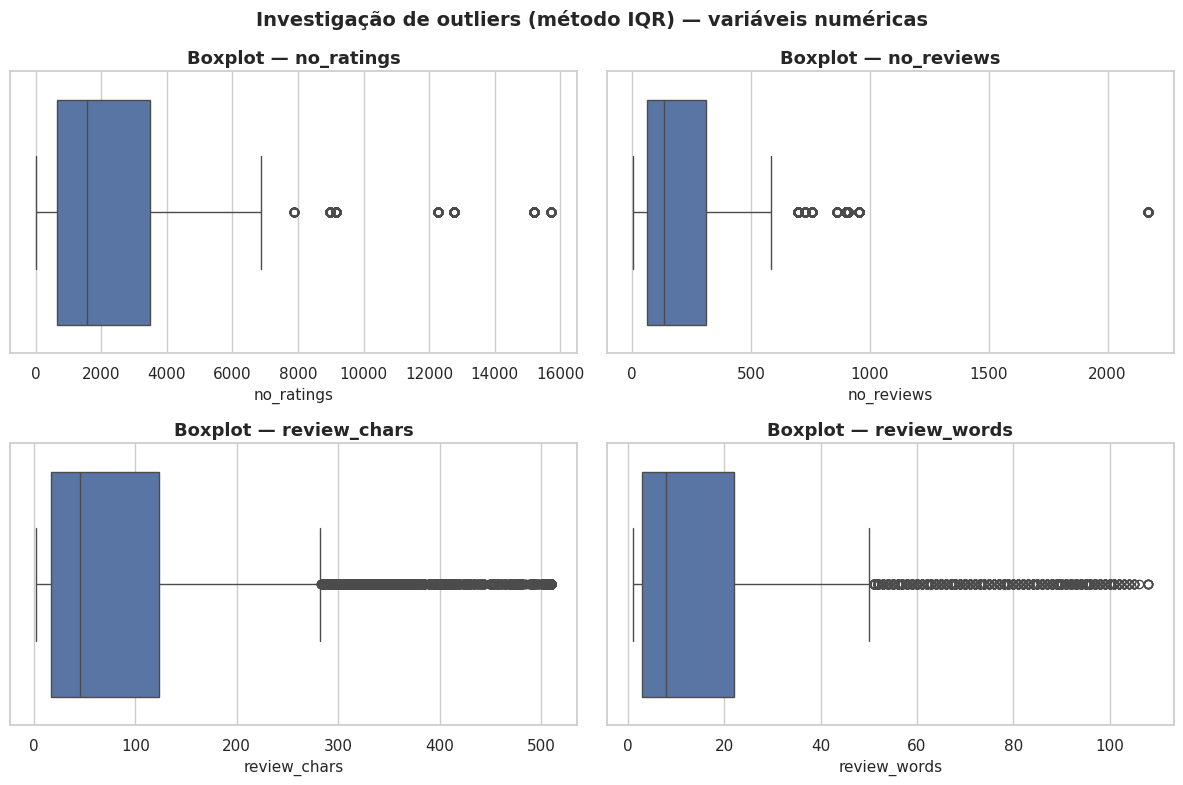

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), ["no_ratings", "no_reviews", "review_chars", "review_words"]):
    sns.boxplot(x=df[col], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot — {col}")
    ax.set_xlabel(col)
fig.suptitle("Investigação de outliers (método IQR) — variáveis numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


O método IQR aponta uma quantidade não desprezível de possíveis outliers
nessas quatro variáveis (percentuais calculados na tabela acima). No entanto, ao interpretar esses
valores à luz do **significado real dos dados**, eles não parecem erros de coleta, e sim
**características legítimas do domínio**:

- em `no_ratings`/`no_reviews`, os valores "extremos" correspondem a **produtos muito populares**
  (best-sellers), que naturalmente acumulam muito mais avaliações que a maioria - é esperado que a
  popularidade de produtos em um marketplace siga uma distribuição de cauda longa;
- em `review_chars`/`review_words`, os valores extremos correspondem a **clientes que escreveram
  avaliações mais detalhadas** (relatos longos de experiência de uso), o que também é um
  comportamento real e útil para o projeto de NLP (reviews mais longas tendem a carregar mais
  informação textual).

Nenhum outlier será removido nesta etapa. Eles representam variação legítima do
fenômeno estudado, não erros de digitação ou falhas de coleta.

## 4. Análise Univariada

### 4.1 Rating (variável-alvo do projeto)

In [ ]:
freq_abs = df["rating"].value_counts().sort_index()
freq_rel = (df["rating"].value_counts(normalize=True) * 100).sort_index().round(2)

rating_summary = pd.DataFrame({"frequência absoluta": freq_abs, "frequência relativa (%)": freq_rel})
rating_summary


,frequência absoluta,frequência relativa (%)
rating,,
1,1809,7.50
2,668,2.77
3,2035,8.44
4,5629,23.34
5,13972,57.94


In [ ]:
media_rating = df["rating"].mean()
mediana_rating = df["rating"].median()
moda_rating = df["rating"].mode()[0]
min_rating = df["rating"].min()
max_rating = df["rating"].max()
std_rating = df["rating"].std()

print(f"Média: {media_rating:.2f}")
print(f"Mediana: {mediana_rating:.2f}")
print(f"Moda: {moda_rating}")
print(f"Mínimo: {min_rating} | Máximo: {max_rating}")
print(f"Desvio-padrão: {std_rating:.2f}")


Média: 4.21
Mediana: 5.00
Moda: 5
Mínimo: 1 | Máximo: 5
Desvio-padrão: 1.18


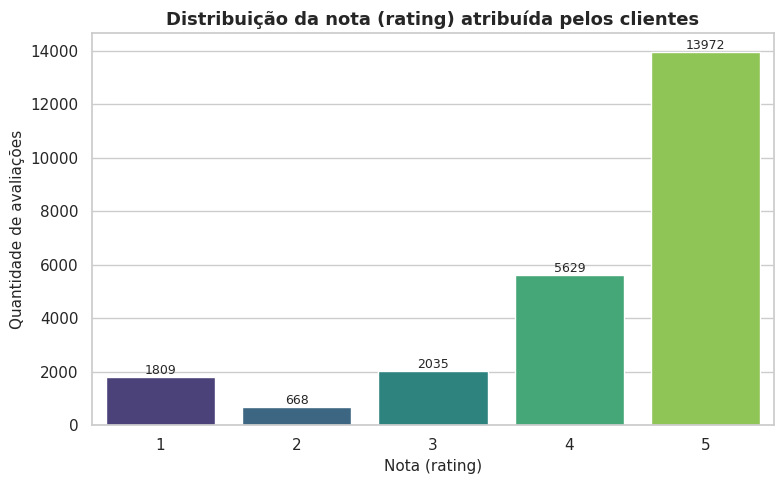

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ordem = sorted(df["rating"].unique())
sns.countplot(x="rating", data=df, order=ordem, ax=ax, palette="viridis")
ax.set_title("Distribuição da nota (rating) atribuída pelos clientes")
ax.set_xlabel("Nota (rating)")
ax.set_ylabel("Quantidade de avaliações")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
pct_classe_majoritaria = freq_rel.max()
classe_majoritaria = freq_rel.idxmax()
pct_classe_minoritaria = freq_rel.min()
classe_minoritaria = freq_rel.idxmin()
razao_desbalanceamento = round(freq_abs.max() / freq_abs.min(), 1)

print(f"Classe majoritária: rating={classe_majoritaria} ({pct_classe_majoritaria}% das avaliações)")
print(f"Classe minoritária: rating={classe_minoritaria} ({pct_classe_minoritaria}% das avaliações)")
print(f"Razão entre a classe mais e a menos frequente: {razao_desbalanceamento}x")


Classe majoritária: rating=5 (57.94% das avaliações)
Classe minoritária: rating=2 (2.77% das avaliações)
Razão entre a classe mais e a menos frequente: 20.9x


Os números calculados acima mostram um **forte desbalanceamento de
classes**: a nota 5 concentra a maior parte das avaliações, enquanto notas intermediárias (2 e 3) são
bem mais raras. Isso é típico de plataformas de e-commerce, em que clientes satisfeitos tendem a
avaliar mais (e mais positivamente) do que clientes neutros.

**Por que isso importa para a classificação multiclasse futura:** se o modelo simplesmente "chutasse"
sempre a classe majoritária (rating 5), ele acertaria uma fração considerável das avaliações (o
percentual calculado acima), o que daria uma **Acurácia (simples) enganosamente alta**, sem que o
modelo tenha realmente aprendido a distinguir sentimentos. É exatamente por isso que o projeto adota
a **Acurácia Balanceada** como métrica: ela calcula a média do recall (sensibilidade) obtido em
**cada classe separadamente**, penalizando fortemente um modelo que ignora as classes minoritárias
(como rating 2), mesmo que ele tenha bom desempenho na classe majoritária.

### 4.2 Variáveis numéricas (overall_rating, no_ratings, no_reviews)

In [ ]:
variaveis_numericas_univariada = ["overall_rating", "no_ratings", "no_reviews"]

resumo_univariado_num = pd.DataFrame({
    col: {
        "média": df[col].mean(),
        "mediana": df[col].median(),
        "mínimo": df[col].min(),
        "máximo": df[col].max(),
        "Q1": df[col].quantile(0.25),
        "Q3": df[col].quantile(0.75),
        "desvio_padrão": df[col].std(),
        "assimetria (skew)": df[col].skew(),
    }
    for col in variaveis_numericas_univariada
}).T

resumo_univariado_num.round(2)


,média,mediana,mínimo,máximo,Q1,Q3,desvio_padrão,assimetria (skew)
overall_rating,4.19,4.2,3.3,5.0,4.1,4.3,0.23,-0.97
no_ratings,2712.26,1569.0,1.0,15729.0,660.0,3475.0,3155.61,2.20
no_reviews,224.71,133.0,1.0,2171.0,62.0,310.0,251.35,2.90


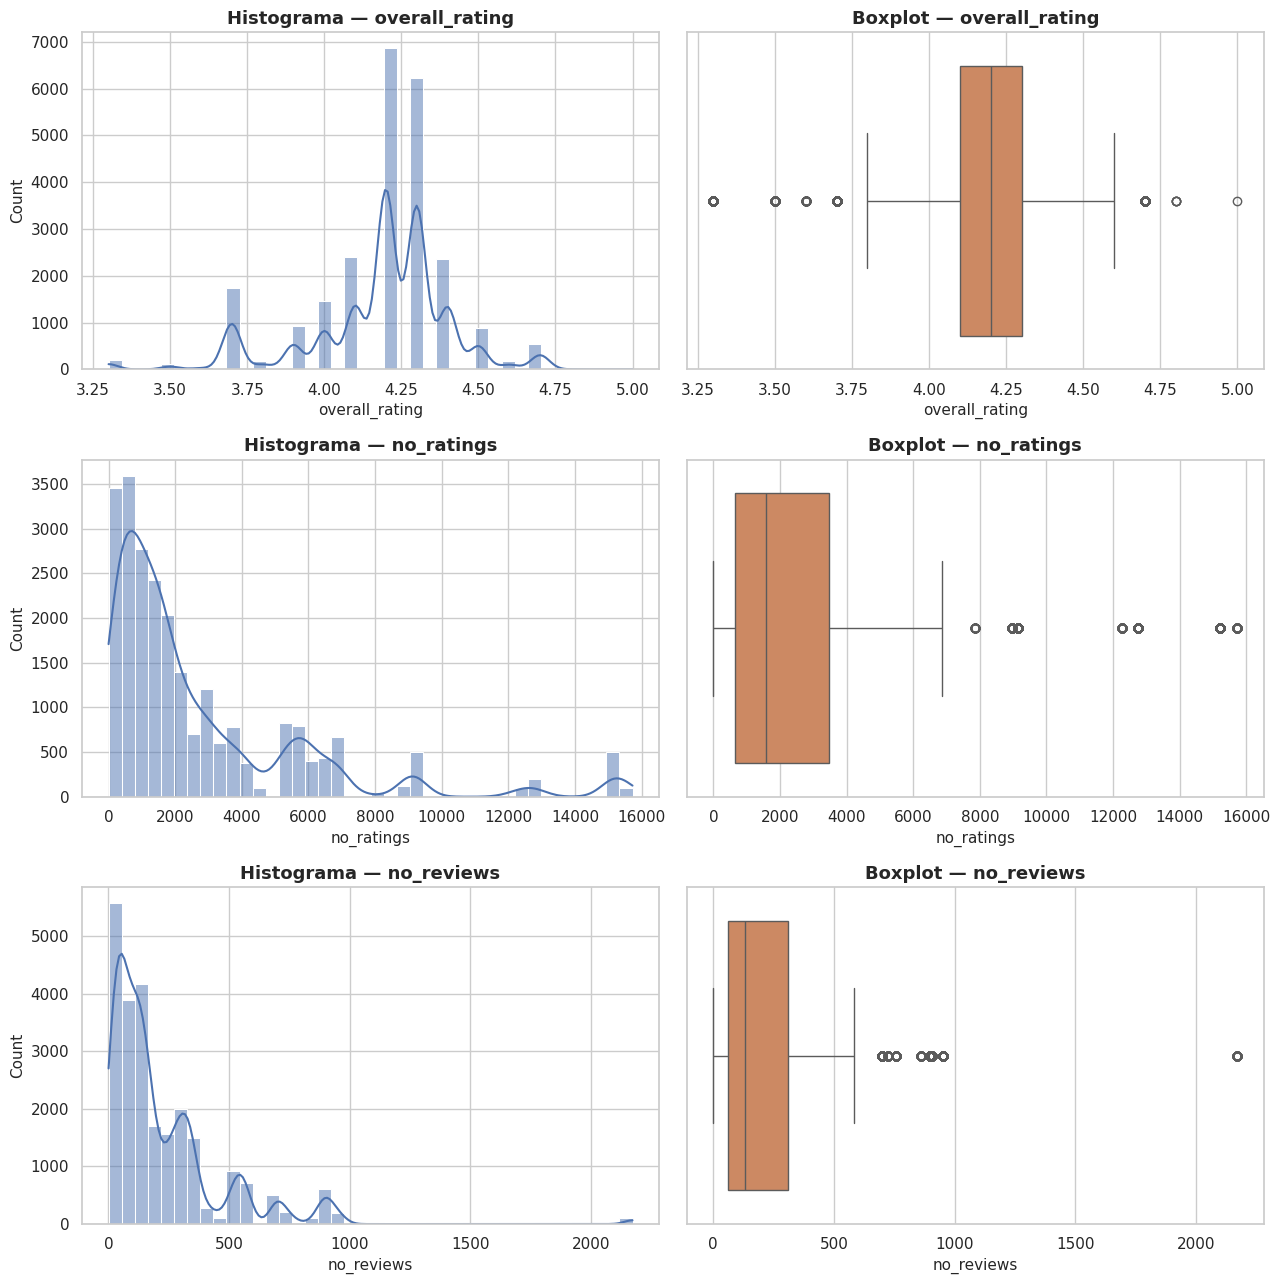

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 13))
for i, col in enumerate(variaveis_numericas_univariada):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i, 0], color="#4C72B0")
    axes[i, 0].set_title(f"Histograma — {col}")
    axes[i, 0].set_xlabel(col)

    sns.boxplot(x=df[col], ax=axes[i, 1], color="#DD8452")
    axes[i, 1].set_title(f"Boxplot — {col}")
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()


`overall_rating` apresenta assimetria **negativa** (cauda mais longa à
esquerda), coerente com o fato de ser uma média por produto concentrada em valores altos (poucos
produtos com média baixa "puxam" a cauda para baixo). Já `no_ratings` e `no_reviews` apresentam
assimetria **positiva** acentuada, a maioria dos produtos tem poucas avaliações, mas alguns produtos
muito populares têm milhares, formando uma cauda longa à direita. Esse padrão de "poucos produtos
dominando o volume de avaliações" já havia sido sinalizado na seção de outliers.

### 4.3 Variáveis categóricas (product_name, title)

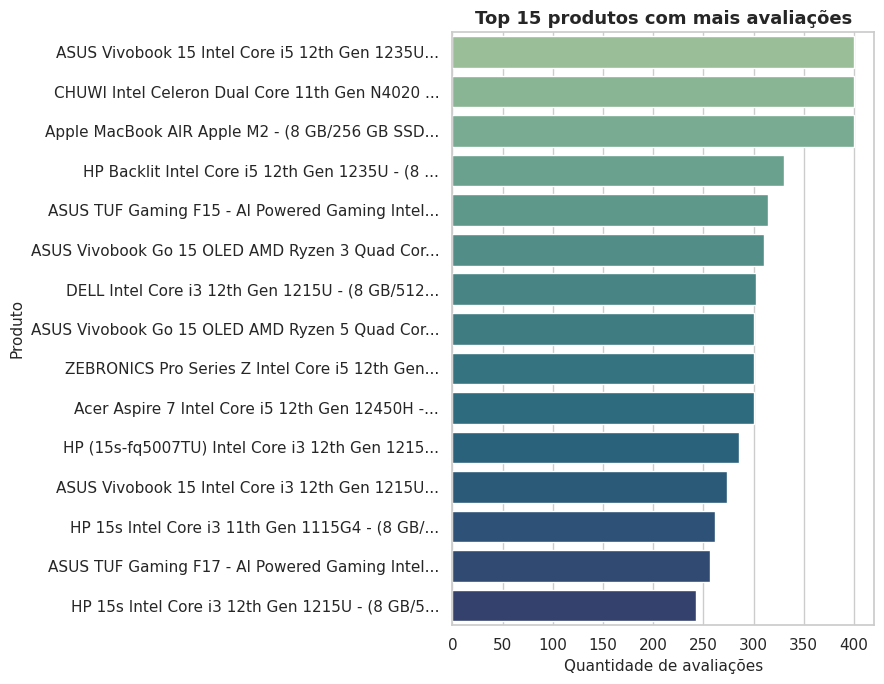

Esses 15 produtos concentram 19.4% de todas as avaliações do dataset.
Número total de produtos distintos: 365
Produtos com apenas 1 avaliação no dataset: 13


In [ ]:
top_n = 15
top_produtos = df["product_name"].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(y=top_produtos.index.str.slice(0, 45) + "...", x=top_produtos.values, ax=ax, palette="crest")
ax.set_title(f"Top {top_n} produtos com mais avaliações")
ax.set_xlabel("Quantidade de avaliações")
ax.set_ylabel("Produto")
plt.tight_layout()
plt.show()

print(f"Esses {top_n} produtos concentram {round(top_produtos.sum()/len(df)*100, 2)}% de todas as avaliações do dataset.")
print(f"Número total de produtos distintos: {df['product_name'].nunique()}")
produtos_com_1_review = (df['product_name'].value_counts() == 1).sum()
print(f"Produtos com apenas 1 avaliação no dataset: {produtos_com_1_review}")


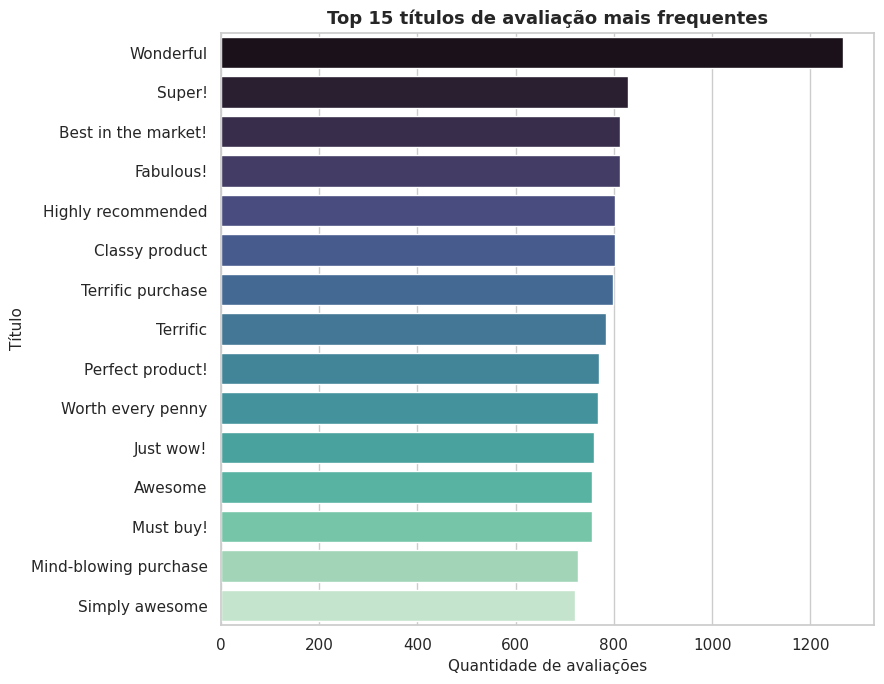

Número de títulos distintos: 213
Títulos que aparecem apenas 1 vez (raros): 81
Os 15 títulos mais comuns concentram 50.43% das avaliações.


In [ ]:
top_n_title = 15
top_titles = df["title"].value_counts().head(top_n_title)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(y=top_titles.index, x=top_titles.values, ax=ax, palette="mako")
ax.set_title(f"Top {top_n_title} títulos de avaliação mais frequentes")
ax.set_xlabel("Quantidade de avaliações")
ax.set_ylabel("Título")
plt.tight_layout()
plt.show()

titles_raros = (df["title"].value_counts() == 1).sum()
print(f"Número de títulos distintos: {df['title'].nunique()}")
print(f"Títulos que aparecem apenas 1 vez (raros): {titles_raros}")
print(f"Os {top_n_title} títulos mais comuns concentram {round(top_titles.sum()/len(df)*100, 2)}% das avaliações.")


`product_name` tem uma cauda longa clássica de marketplace - poucos
produtos concentram uma fatia desproporcional das avaliações (percentual calculado acima), enquanto
muitos produtos têm pouquíssimas avaliações. Já `title` é dominado por um conjunto pequeno de
expressões positivas e genéricas, reforçando a leitura de que a plataforma recebe majoritariamente
feedback positivo, consistente com o desbalanceamento observado em `rating` (seção 4.1).

### 4.4 Variáveis textuais (tamanho das reviews)

In [ ]:
resumo_texto = pd.DataFrame({
    "review_chars": df["review_chars"].describe(),
    "review_words": df["review_words"].describe(),
}).T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
resumo_texto.round(2)


,count,mean,std,min,25%,50%,75%,max
review_chars,24113.0,96.91,122.46,2.0,17.0,46.0,123.0,510.0
review_words,24113.0,17.47,22.18,1.0,3.0,8.0,22.0,108.0


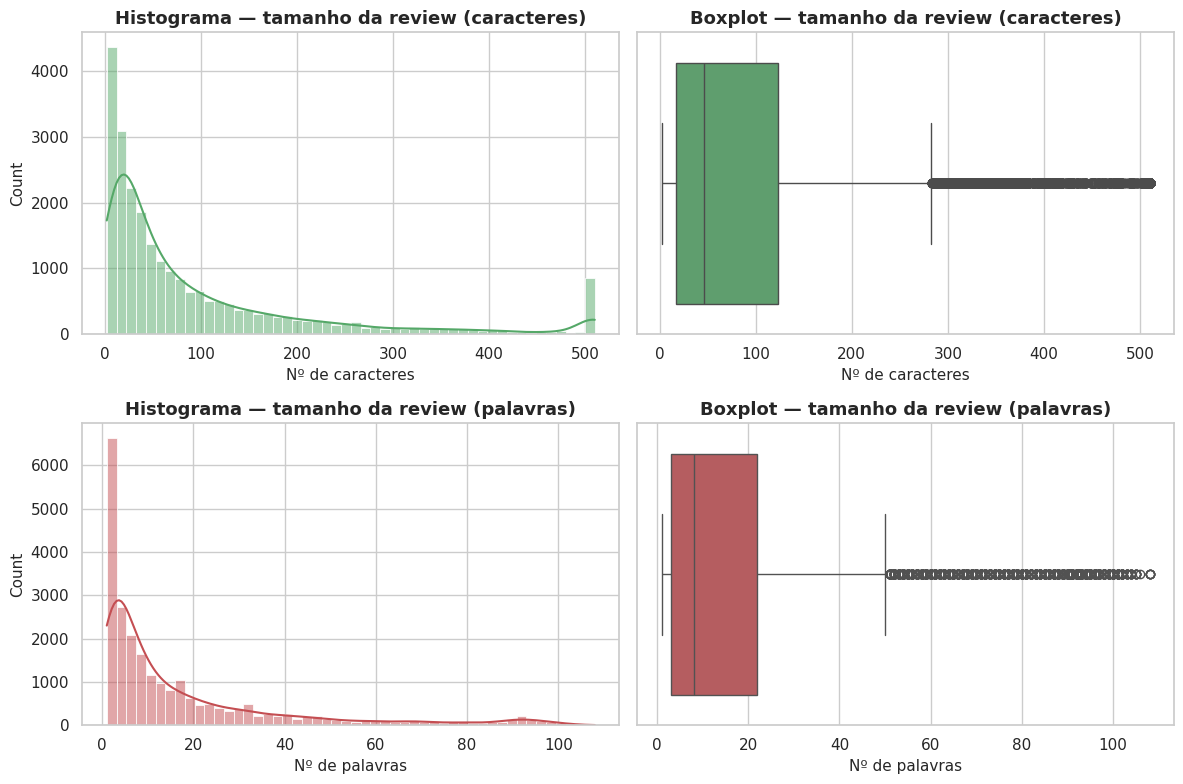

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["review_chars"], bins=50, kde=True, ax=axes[0, 0], color="#55A868")
axes[0, 0].set_title("Histograma — tamanho da review (caracteres)")
axes[0, 0].set_xlabel("Nº de caracteres")

sns.boxplot(x=df["review_chars"], ax=axes[0, 1], color="#55A868")
axes[0, 1].set_title("Boxplot — tamanho da review (caracteres)")
axes[0, 1].set_xlabel("Nº de caracteres")

sns.histplot(df["review_words"], bins=50, kde=True, ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Histograma — tamanho da review (palavras)")
axes[1, 0].set_xlabel("Nº de palavras")

sns.boxplot(x=df["review_words"], ax=axes[1, 1], color="#C44E52")
axes[1, 1].set_title("Boxplot — tamanho da review (palavras)")
axes[1, 1].set_xlabel("Nº de palavras")

plt.tight_layout()
plt.show()


In [ ]:
reviews_curtas_5_palavras = (df["review_words"] <= 5).sum()
print(f"Avaliações com 5 palavras ou menos: {reviews_curtas_5_palavras} "
      f"({round(reviews_curtas_5_palavras/len(df)*100, 2)}% do dataset)")

reviews_longas_50_palavras = (df["review_words"] >= 50).sum()
print(f"Avaliações com 50 palavras ou mais: {reviews_longas_50_palavras} "
      f"({round(reviews_longas_50_palavras/len(df)*100, 2)}% do dataset)")


Avaliações com 5 palavras ou menos: 9373 (38.87% do dataset)
Avaliações com 50 palavras ou mais: 2260 (9.37% do dataset)


A distribuição do tamanho das reviews é fortemente assimétrica à direita -
a mediana é bem menor que a média, e uma parcela relevante das avaliações (percentual calculado acima)
tem 5 palavras ou menos (ex.: "Good", "Nice product", "Value for money"). Isso é um ponto de atenção
importante para a etapa futura de NLP: **avaliações muito curtas carregam pouca informação textual**,
o que pode dificultar a tarefa de classificação multiclasse, especialmente para diferenciar notas
intermediárias (2, 3, 4), que dependem de nuances de linguagem mais difíceis de captar em frases
curtas e genéricas.

## 6. Visualização dos Dados

A maior parte dos gráficos relevantes para esta EDA já foi apresentada ao longo das seções anteriores
(univariada, bivariada e multivariada), sempre junto ao código que os gera e à interpretação dos
resultados - evitando gráficos soltos ou redundantes. Nesta seção, consolidamos apenas **duas
visualizações complementares** que ajudam a resumir os achados principais: (1) um painel-resumo do
desbalanceamento de classes lado a lado com o tamanho médio das reviews por classe, e (2) uma
exploração leve e puramente descritiva do vocabulário mais frequente nas reviews extremas (nota 1 vs.
nota 5), **sem qualquer técnica de vetorização/NLP**, apenas contagem simples de palavras, como
extensão natural da análise textual univariada.

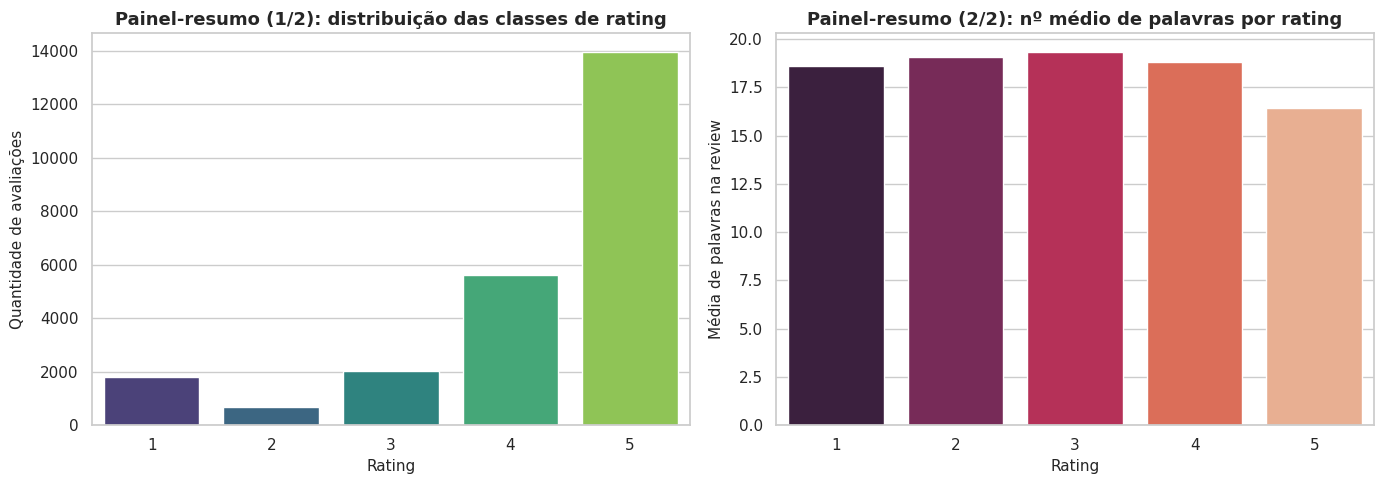

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ordem = sorted(df["rating"].unique())
sns.countplot(x="rating", data=df, order=ordem, ax=axes[0], palette="viridis")
axes[0].set_title("Painel-resumo (1/2): distribuição das classes de rating")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Quantidade de avaliações")

media_palavras_por_rating = df.groupby("rating")["review_words"].mean()
sns.barplot(x=media_palavras_por_rating.index, y=media_palavras_por_rating.values, ax=axes[1], palette="rocket")
axes[1].set_title("Painel-resumo (2/2): nº médio de palavras por rating")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Média de palavras na review")

plt.tight_layout()
plt.show()


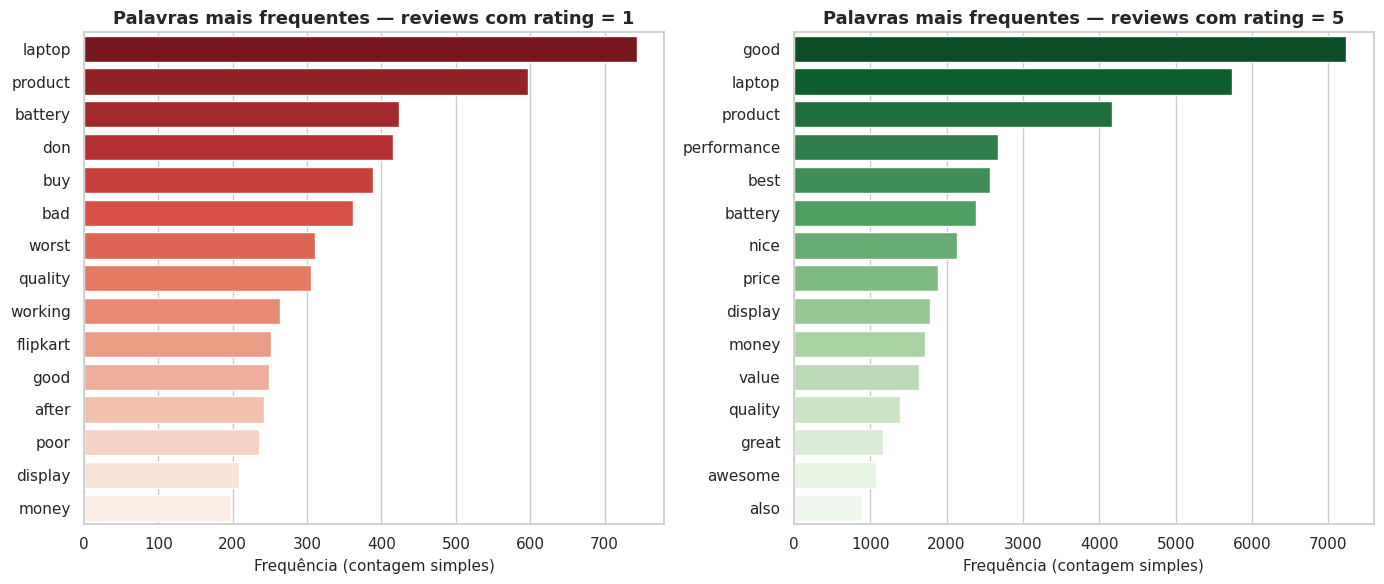

In [ ]:
import re
from collections import Counter

STOPWORDS_BASICAS = {
    "the", "a", "an", "is", "it", "to", "and", "for", "of", "in", "this", "that", "i", "my",
    "with", "on", "very", "so", "but", "as", "at", "was", "are", "have", "has", "not", "its",
    "you", "your", "be", "or", "all", "from", "which", "just", "can", "will", "one", "than",
}

def top_palavras(textos, n=15):
    palavras = []
    for t in textos.astype(str):
        tokens = re.findall(r"[a-zA-Z]+", t.lower())
        palavras.extend([tok for tok in tokens if tok not in STOPWORDS_BASICAS and len(tok) > 2])
    return Counter(palavras).most_common(n)

top_rating_1 = top_palavras(df.loc[df["rating"] == 1, "review"])
top_rating_5 = top_palavras(df.loc[df["rating"] == 5, "review"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

palavras1, contagens1 = zip(*top_rating_1)
sns.barplot(x=list(contagens1), y=list(palavras1), ax=axes[0], palette="Reds_r")
axes[0].set_title("Palavras mais frequentes — reviews com rating = 1")
axes[0].set_xlabel("Frequência (contagem simples)")

palavras5, contagens5 = zip(*top_rating_5)
sns.barplot(x=list(contagens5), y=list(palavras5), ax=axes[1], palette="Greens_r")
axes[1].set_title("Palavras mais frequentes — reviews com rating = 5")
axes[1].set_xlabel("Frequência (contagem simples)")

plt.tight_layout()
plt.show()


O painel-resumo reforça visualmente os dois achados centrais da EDA: (1) o
forte desbalanceamento das classes de rating, e (2) a leve tendência de reviews mais curtas na classe
majoritária (rating 5). A comparação de palavras mais frequentes entre rating 1 e rating 5 (mesmo com
uma contagem simples, sem NLP completo) já sugere vocabulários distintos entre avaliações negativas e
positiva.

## 7. Padrões, Tendências e Anomalias

Nesta seção, sintetizamos, sem repetir gráficos, apenas interpretando o que já foi calculado, os
principais padrões observados, distinguindo sempre entre **resultado observado** (calculado
diretamente dos dados) e **hipótese possível** (explicação não comprovada com os dados disponíveis).

**Padrões observados (calculados nas seções anteriores):**

1. **Predominância de notas altas.** A classe rating=5 é a mais frequente (percentual calculado na
   seção 4.1), seguida por rating=4. Notas intermediárias (2 e 3) são bem mais raras. *(Resultado
   observado.)*
2. **Desbalanceamento severo de classes.** A razão entre a classe mais e a menos frequente (calculada
   na seção 4.1) mostra que um classificador ingênuo teria desempenho enganosamente alto em Acurácia
   simples, mas baixo em Acurácia Balanceada. *(Resultado observado - motivação direta para a métrica
   do projeto.)*
3. **Duplicação elevada de linhas**, concentrada em textos curtos e genéricos (seção 3.2). *(Resultado
   observado.)* A **hipótese** de que isso decorre de coincidência entre clientes distintos que
   escrevem frases muito comuns (e não de erro de coleta) é plausível e sustentada pelos exemplos
   inspecionados, mas não pode ser comprovada com 100% de certeza sem metadados adicionais (como
   identificador único de cliente ou timestamp), que **não existem neste dataset**.
4. **Distribuição de popularidade em cauda longa.** Poucos produtos concentram grande parte das
   avaliações (`no_ratings`, `no_reviews`, seções 2.5.1/3.6/4.3), enquanto muitos produtos têm poucas
   avaliações. *(Resultado observado, com base nos percentuais calculados.)*
5. **Reviews predominantemente curtas.** Uma parcela relevante do dataset tem 5 palavras ou menos
   (seção 4.4). *(Resultado observado.)* Isso é uma característica real do comportamento dos
   clientes na plataforma, não um problema de coleta.
6. **Relação fraca entre tamanho do texto e rating.** Existe uma leve tendência de reviews de rating 5
   serem mais curtas (seção 5.5), mas a correlação calculada é fraca. *(Resultado observado.)* A
   **hipótese** de que isso ocorre porque clientes insatisfeitos "explicam mais" o motivo da nota
   baixa é razoável, mas não comprovada - não afirmamos causalidade.
7. **Não há anomalias graves de qualidade de dados.** Não foram encontrados valores ausentes,
   valores fora de escala, contagens negativas ou inconsistências lógicas entre `no_ratings` e
   `no_reviews` (seção 3.4). *(Resultado observado.)* Os "outliers" identificados pelo método IQR
   (seção 3.6) foram interpretados como características legítimas (produtos populares, reviews
   detalhadas), não como erros.

Não identificamos, nesta etapa, nenhuma tendência temporal (por não haver variável de data) nem
nenhuma anomalia que sugira erro de coleta dos dados.

### 7.1 Anomalia adicional: produtos populares com nota média abaixo do esperado

Além dos padrões já discutidos, investigamos se existem produtos com volume alto de avaliações
(portanto, com uma média mais confiável estatisticamente, menos sujeita a coincidência de poucas
avaliações) mas cujo rating médio fica abaixo do restante do dataset.

In [ ]:
# 7.1 Anomalia adicional: produtos populares com nota média abaixo do esperado
resumo_por_produto = df.groupby("product_name").agg(
    n_avaliacoes=("rating", "size"),
    rating_medio=("rating", "mean")
).reset_index()

rating_medio_geral = df["rating"].mean()
limite_avaliacoes = resumo_por_produto["n_avaliacoes"].quantile(0.75)

produtos_atencao = resumo_por_produto[
    (resumo_por_produto["n_avaliacoes"] >= limite_avaliacoes) &
    (resumo_por_produto["rating_medio"] < rating_medio_geral - 0.5)
].sort_values("rating_medio")

print(f"Rating médio geral do dataset: {rating_medio_geral:.2f}")
print(f"Volume considerado 'alto' (percentil 75 de avaliações por produto): {limite_avaliacoes:.0f}")
print(f"\nProdutos com volume alto de avaliações e rating médio abaixo do esperado: {len(produtos_atencao)}\n")
produtos_atencao.head(10)

O resultado acima mostra produtos com volume de avaliações no quartil superior do dataset, mas com
rating médio consistentemente abaixo da média geral. *(Resultado observado.)* Como o volume alto
reduz a chance de isso ser coincidência estatística de poucas avaliações, é razoável levantar a
**hipótese** de que esses produtos possuem problemas reais de qualidade percebida pelos clientes,
não comprovável com certeza sem dados adicionais, mas consistente
com o padrão observado. Esses casos podem servir como exemplos de teste interessantes para verificar se o modelo classifica corretamente reviews negativas mesmo vindas
de produtos "populares".

## 8. Principais Insights

A célula de código abaixo recalcula, de forma consolidada, os números centrais que sustentam os
insights desta EDA (todos já demonstrados individualmente ao longo do notebook).

In [ ]:
print("=== Resumo consolidado dos principais números da EDA ===\n")

print(f"1) Total de avaliações: {len(df)} | Total de produtos distintos: {df['product_name'].nunique()}")

print(f"\n2) Distribuição de rating (%):")
print((df['rating'].value_counts(normalize=True) * 100).sort_index().round(2))

print(f"\n3) Razão entre classe mais e menos frequente de rating: "
      f"{round(df['rating'].value_counts().max() / df['rating'].value_counts().min(), 1)}x")

print(f"\n4) Linhas totalmente duplicadas: {df.duplicated().sum()} "
      f"({round(df.duplicated().sum()/len(df)*100, 2)}%)")

print(f"\n5) Valores ausentes no dataset inteiro: {int(df.isna().sum().sum())}")

top10_pct = round(df['product_name'].value_counts().head(10).sum() / len(df) * 100, 2)
print(f"\n6) Percentual das avaliações concentrado nos 10 produtos mais avaliados: {top10_pct}%")

print(f"\n7) Tamanho da review (palavras) — média: {df['review_words'].mean():.2f}, "
      f"mediana: {df['review_words'].median():.1f}, máximo: {df['review_words'].max()}")

pct_reviews_curtas = round((df['review_words'] <= 5).sum() / len(df) * 100, 2)
print(f"\n8) Avaliações com 5 palavras ou menos: {pct_reviews_curtas}%")

corr_rating_words = df['rating'].corr(df['review_words'])
print(f"\n9) Correlação (Pearson) entre rating e nº de palavras da review: {corr_rating_words:.3f} (fraca)")

media_palavras_rating5 = df.loc[df['rating']==5, 'review_words'].mean()
media_palavras_rating1 = df.loc[df['rating']==1, 'review_words'].mean()
print(f"\n10) Média de palavras: rating 5 = {media_palavras_rating5:.1f} | rating 1 = {media_palavras_rating1:.1f}")


=== Resumo consolidado dos principais números da EDA ===

1) Total de avaliações: 24113 | Total de produtos distintos: 365

2) Distribuição de rating (%):
rating
1     7.50
2     2.77
3     8.44
4    23.34
5    57.94
Name: proportion, dtype: float64

3) Razão entre classe mais e menos frequente de rating: 20.9x

4) Linhas totalmente duplicadas: 7122 (29.54%)

5) Valores ausentes no dataset inteiro: 0

6) Percentual das avaliações concentrado nos 10 produtos mais avaliados: 13.92%

7) Tamanho da review (palavras) — média: 17.47, mediana: 8.0, máximo: 108

8) Avaliações com 5 palavras ou menos: 38.87%

9) Correlação (Pearson) entre rating e nº de palavras da review: -0.042 (fraca)

10) Média de palavras: rating 5 = 16.4 | rating 1 = 18.6


Com base nos números acima, destacamos os seguintes insights específicos deste dataset:

**Insight 1 — Desbalanceamento severo é o principal desafio do projeto.**
A distribuição de `rating` (item 2 e 3 acima) mostra que a classe 5 domina o dataset, com razão de
desbalanceamento expressiva em relação à classe minoritária.

**Insight 2 — Duplicatas são um fenômeno real do domínio, não erro de coleta.**
Quase um terço das linhas são duplicatas completas (item 4), mas a inspeção manual (seção 3.2) mostrou
que isso decorre de textos curtos e genéricos repetidos por clientes diferentes no mesmo produto.


**Insight 3 — Qualidade estrutural dos dados é alta.**
Não há valores ausentes (item 5), nem notas fora de escala, nem contagens negativas ou inconsistências
lógicas.

**Insight 4 — Popularidade de produtos segue cauda longa.**
Uma minoria de produtos concentra uma fração desproporcional das avaliações (item 6).

**Insight 5 — Reviews são, em geral, curtas - e isso é um desafio para o NLP.**
Uma parcela relevante das avaliações tem 5 palavras ou menos (item 8), reduzindo o contexto textual
disponível para o classificador.

**Insight 6 — O tamanho do texto por si só é um preditor fraco do rating.**
A correlação calculada no item 9 é fraca, apesar de existir uma diferença perceptível entre a média de
palavras de rating 5 e rating 1 (item 10).

## 9. Conclusão da Análise Exploratória

**Principais descobertas:** O dataset de reviews de laptops da Flipkart contém aproximadamente 24 mil
avaliações de clientes sobre centenas de modelos distintos, sem valores ausentes e sem inconsistências
estruturais graves. A variável-alvo (`rating`) é fortemente desbalanceada em favor de notas altas, e o
texto das avaliações é tipicamente curto, com uma fração relevante de reviews de poucas palavras.

**Principais insights:** Foram detalhados na Seção 8: desbalanceamento severo de classes, natureza
não-anômala das duplicatas (fenômeno do domínio, não erro), alta qualidade estrutural dos dados,
concentração de avaliações em poucos produtos (cauda longa), predominância de reviews curtas e relação
fraca - mas presente - entre tamanho do texto e rating.

**Qualidade dos dados:** De forma geral, **alta**: zero valores ausentes, zero valores fora dos
intervalos válidos definidos pelo significado das variáveis, e apenas dois problemas de tipo
(`no_ratings`/`no_reviews` como texto), já corrigidos nesta própria etapa. O principal ponto de
atenção é o volume de linhas duplicadas, tratado com cautela e não removido automaticamente.

**Desbalanceamento das classes:** Confirmado numericamente na Seção 4.1: a nota 5 domina amplamente o
dataset. Esse é o achado mais crítico para as próximas etapas - sem tratamento adequado, qualquer
modelo tenderá a favorecer a classe majoritária, o que a Acurácia Balanceada é desenhada para expor.

**Limitações desta análise:**
- Não existe nenhuma variável temporal no dataset, o que impede qualquer análise de evolução das
  notas/reviews ao longo do tempo ou de sazonalidade.
- Não há identificador de cliente, o que impede saber se um mesmo cliente avaliou múltiplos produtos
  ou se compras/avaliações são de clientes distintos - isso limita a certeza sobre a natureza exata
  das duplicatas (tratada como hipótese razoável, não como fato comprovado).

**Questões em aberto:**
- Qual estratégia de balanceamento (reamostragem, pesos de classe, ou ambas) funcionará melhor dado o
  grau de desbalanceamento ?
- As reviews duplicadas devem ser removidas, mantidas, ou tratadas de forma especial na divisão
  treino/teste, para evitar vazamento de dados?